In [2]:
import numpy as np
import time

def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        left_half = arr[:mid]
        right_half = arr[mid:]

        merge_sort(left_half)
        merge_sort(right_half)

        i = j = k = 0
        while i < len(left_half) and j < len(right_half):
            if left_half[i] < right_half[j]:
                arr[k] = left_half[i]
                i += 1
            else:
                arr[k] = right_half[j]
                j += 1
            k += 1

        while i < len(left_half):
            arr[k] = left_half[i]
            i += 1
            k += 1

        while j < len(right_half):
            arr[k] = right_half[j]
            j += 1
            k += 1

def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    return quick_sort(left) + middle + quick_sort(right)


In [3]:
def measure_time(sort_func, arr):
    start_time = time.time()
    sort_func(arr.copy())  # Use a copy to avoid in-place sorting
    return time.time() - start_time


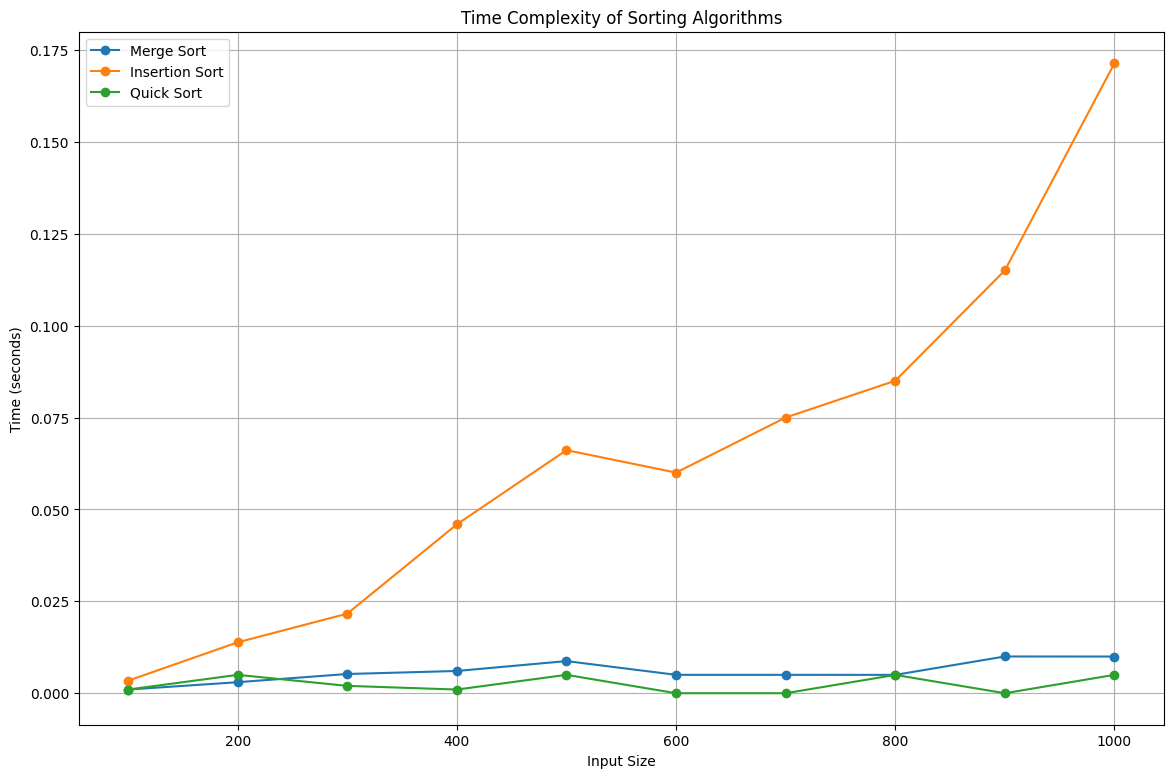

In [12]:
import matplotlib.pyplot as plt

input_sizes = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
merge_times = []
insertion_times = []
quick_times = []

plt.figure(figsize=(14, 9))

for size in input_sizes:
    arr = np.random.randint(0, 10000, size)

    merge_times.append(measure_time(merge_sort, arr))
    insertion_times.append(measure_time(insertion_sort, arr))
    quick_times.append(measure_time(quick_sort, arr))

plt.plot(input_sizes, merge_times, label='Merge Sort', marker='o')
plt.plot(input_sizes, insertion_times, label='Insertion Sort', marker='o')
plt.plot(input_sizes, quick_times, label='Quick Sort', marker='o')

plt.xlabel('Input Size')
plt.ylabel('Time (seconds)')
plt.title('Time Complexity of Sorting Algorithms')
plt.legend()
plt.grid(True)
plt.show()
